# Visualizing Tensor Accesses Over Time

This notebook shows a visualization of the order in which tensor elements are accessed from a LoopTree.

## An unfused mapping

We start with a chain of matrix multiplications, 
mapped onto the simple architecture without fusion.

In [9]:
import accelforge as af

spec = af.Spec.from_yaml(
    af.examples.arches.simple,
    af.examples.workloads.basic.matmuls,
    af.examples.mappings.unfused_matmuls_to_simple,
    jinja_parse_data={"N_EINSUMS": 2, "M": 4, "KN": 3},
)
results = spec.evaluate_mapping()

The architecture is a simple one, with just MainMemory, GlobalBuffer, and a MAC.

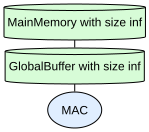

In [10]:
spec.arch

The mapping, in LoopTree notation, is shown below:

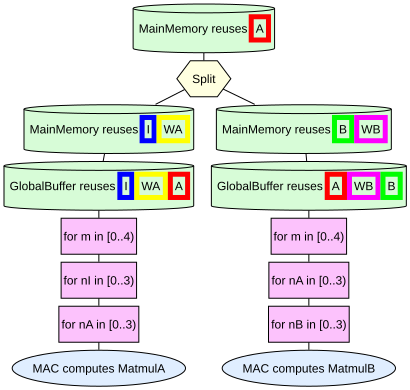

In [11]:
results.render(with_tile_shape=False, with_reservations=False)

Below, `plot_access_trace` visualizes which element is accessed at each timestep.
Different colors show different Einsums.

(<Figure size 650x1060 with 5 Axes>,
 [<Axes: title={'left': 'I  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'WA  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'A  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'WB  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'B  [4x3]'}, xlabel='Timestep', ylabel='Element'>])

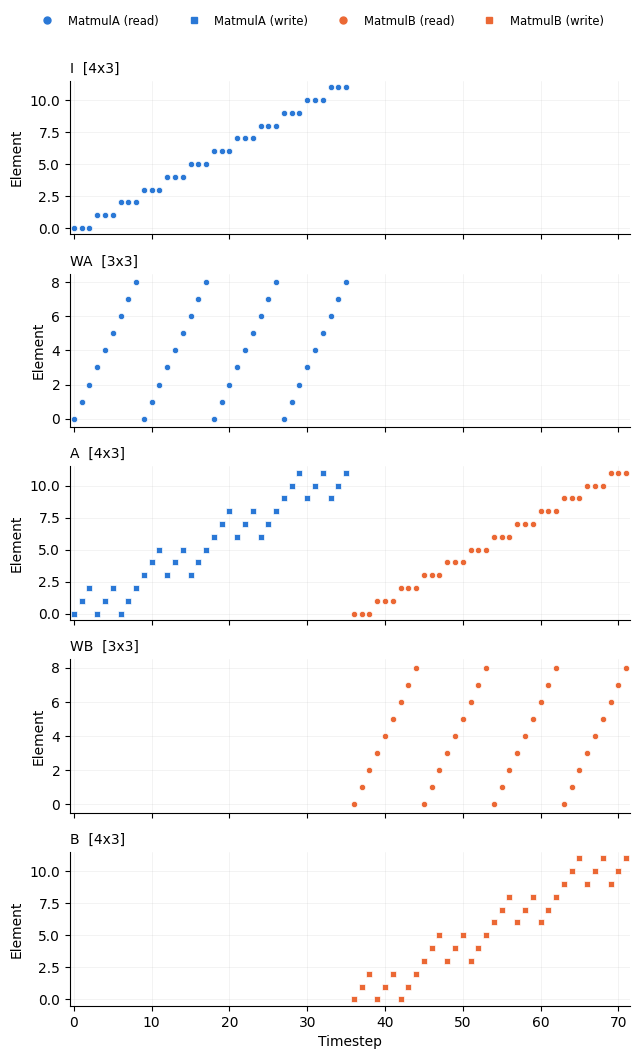

In [12]:
from accelforge.plotting import plot_access_trace

plot_access_trace(spec)

Reading the plot from the top:

- **I** is repeatedly accessed one at a time because the `m` loop is outermost. That is, the dataflow is **I**-stationary.
- **WA** is accessed from the first to last element (*i.e.*, *scanned*) for each iteration of `m` and `nI`.
- **A** is written by MatmulA in the first half of the timesteps and read by
  MatmulB in the second half. **A** is *tile stationary* in MatmulA and stationary in MatmulB.
- **WB** is scanned repeatedly like **WA**.
- **B** is tile stationary in MatmulB.

Note how the entirety of **B** is produced before any of it is consumed.

## Tiled, Fused Mapping

Now, we study a mapping that produces and consumes **T1** one tile at a time.

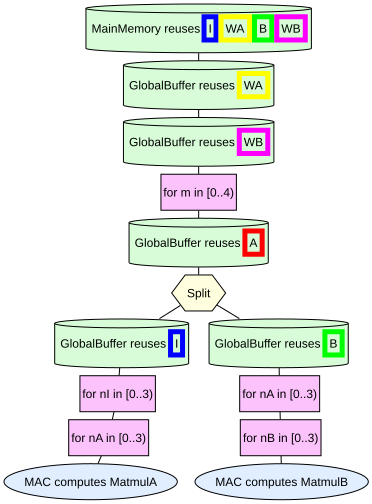

In [13]:
fused = af.Spec.from_yaml(
    af.examples.arches.simple,
    af.examples.workloads.basic.matmuls,
    af.examples.mappings.fused_matmuls_to_simple,
    jinja_parse_data={"N_EINSUMS": 2, "M": 4, "KN": 3},
)
fused_results = fused.evaluate_mapping()
fused_results.render(with_tile_shape=False, with_reservations=False)

(<Figure size 650x1060 with 5 Axes>,
 [<Axes: title={'left': 'I  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'WA  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'A  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'WB  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'B  [4x3]'}, xlabel='Timestep', ylabel='Element'>])

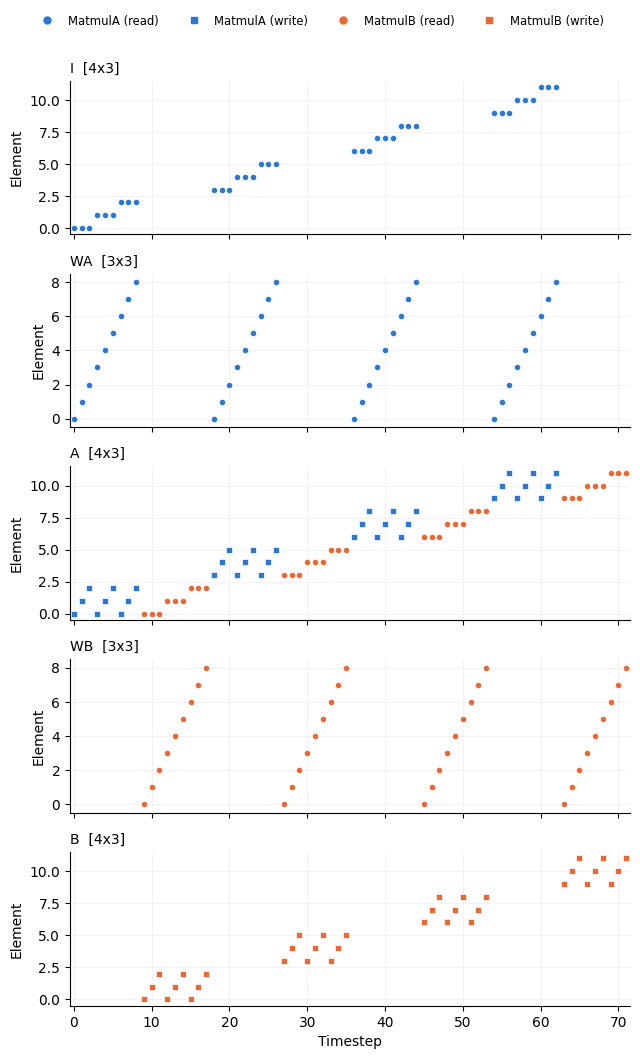

In [14]:
plot_access_trace(fused)

## Visualizing Tiles in Memory

The points show accessed tensor elements; If `memory_level` parameter is set, then the tensor
elements in the in-memory tile is shaded.

(<Figure size 650x1060 with 5 Axes>,
 [<Axes: title={'left': 'I  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'WA  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'A  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'WB  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'B  [4x3]'}, xlabel='Timestep', ylabel='Element'>])

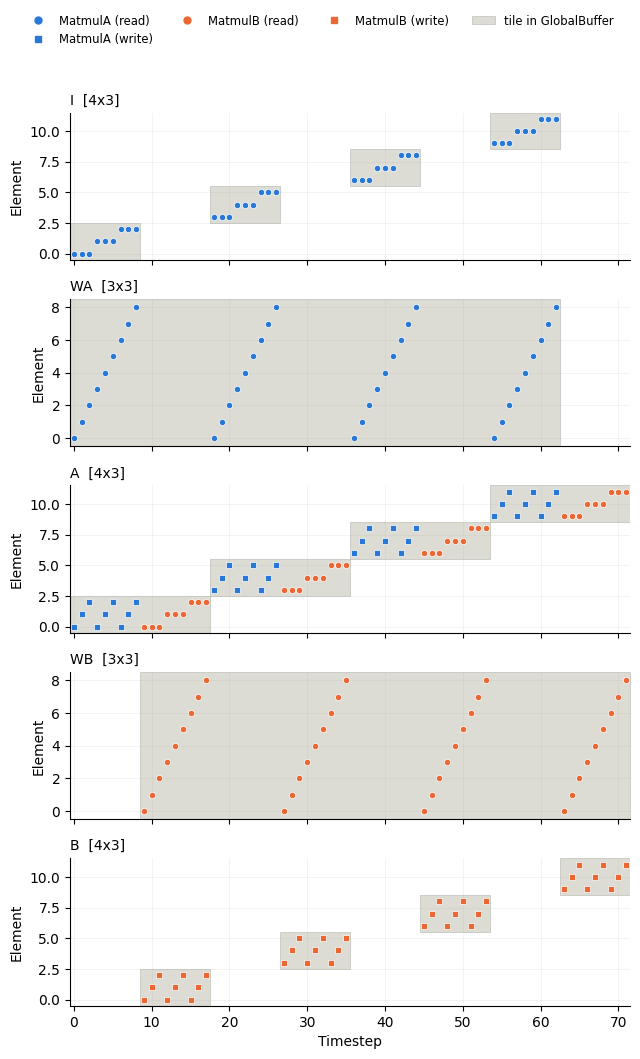

In [15]:
plot_access_trace(fused, memory_level="GlobalBuffer")


The **WA** and **WB** tiles live the entire time because their
`GlobalBuffer` storage sits above the `m` loop so the weights are
fetched once and reused.

On the other hand, **I**, **A**, and **B** fetch a new tile per
iteration of `m`.